# 📊 Notebook 10 — Évaluation Finale & Interface Gradio

---

## 1. Installation

In [1]:
!pip install gradio rouge-score nltk sentence-transformers faiss-cpu transformers accelerate torch rank-bm25 networkx pandas matplotlib seaborn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/19.7 MB ? eta -:--:--
   -- ------------------------------------- 1.3/19.7 MB 6.1 MB/s eta 0:00:04
   ----- ---------------------------------- 2.9/19.7 MB 6.8 MB/s eta 0:00:03
   -------- ------------------------------- 4.2/19.7 MB 6.9 MB/s eta 0:00:03
   ----------- -----


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [3]:
import json, pickle, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import nltk
import faiss, torch
import gradio as gr

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM , GenerationConfig
from rank_bm25 import BM25Okapi

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
sns.set_theme(style='whitegrid')
DEVICE = 0 if torch.cuda.is_available() else -1
print(' Imports OK')
print(f'   Gradio version : {gr.__version__}')

 Imports OK
   Gradio version : 6.14.0


## 3. Chargement de tous les résultats

In [4]:
result_files = {
    'baseline'   : '../Results/results_baseline.json',
    'rag_classic': '../Results/results_rag_classic.json',
    'rag_rerank' : '../Results/results_rag_rerank.json',
    'rag_hybrid' : '../Results/results_rag_hybrid.json',
    'multi_hop'  : '../Results/results_multi_hop.json',
    'graph_rag'  : '../Results/results_graph_rag.json',
    'agentic_rag': '../Results/results_agentic_rag.json'
}

all_results = {}
for method, filepath in result_files.items():
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            all_results[method] = json.load(f)
        print(f' {method:15s} : {len(all_results[method])} résultats chargés')
    except FileNotFoundError:
        print(f'  {method:15s} : fichier non trouvé — exécuter le notebook correspondant')

TEST_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur le protocole SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware qui chiffre des fichiers via SMB",
    "Repérer une exfiltration de données via le protocole DNS"
]
print(f'\n {len(all_results)} architectures chargées')

 baseline        : 5 résultats chargés
 rag_classic     : 5 résultats chargés
 rag_rerank      : 5 résultats chargés
 rag_hybrid      : 5 résultats chargés
 multi_hop       : 5 résultats chargés
 graph_rag       : 5 résultats chargés
 agentic_rag     : 5 résultats chargés

 7 architectures chargées


## 4. Références ground truth (règles attendues)

In [5]:
# Règles de référence pour les 5 requêtes de test
GROUND_TRUTH = [
    'alert tcp any any -> $HOME_NET 80 (msg:"SYN Scan détecté"; flags:S; threshold:type both, track by_src, count 20, seconds 5; sid:1000001; rev:1;)',
    'alert tcp any any -> $HOME_NET 22 (msg:"SSH Brute Force"; threshold:type both, track by_src, count 10, seconds 60; sid:1000003; rev:1;)',
    'alert tcp any any -> $HOME_NET 80 (msg:"SQL Injection GET"; content:"GET"; http_method; content:"union+select"; nocase; http_uri; sid:1000004; rev:1;)',
    'alert tcp $HOME_NET any -> $HOME_NET 445 (msg:"Ransomware SMB Encryption"; content:"|FF 53 4D 42 25|"; threshold:type both, track by_src, count 100, seconds 10; sid:1000040; rev:1;)',
    'alert udp $HOME_NET any -> any 53 (msg:"DNS Data Exfiltration"; content:"TXT"; threshold:type both, track by_src, count 50, seconds 10; sid:1000017; rev:1;)'
]
print(f' {len(GROUND_TRUTH)} règles de référence définies')

 5 règles de référence définies


## 5. Fonctions de métriques

In [6]:
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1


def compute_bleu(hypothesis: str, reference: str) -> float:
    """BLEU score entre la règle générée et la référence."""
    try:
        hyp_tokens = hypothesis.lower().split()
        ref_tokens = reference.lower().split()
        if not hyp_tokens:
            return 0.0
        return round(sentence_bleu([ref_tokens], hyp_tokens,
                                    smoothing_function=smooth), 4)
    except Exception:
        return 0.0


def compute_rouge(hypothesis: str, reference: str) -> dict:
    """ROUGE-1, ROUGE-2, ROUGE-L entre la règle générée et la référence."""
    try:
        scores = rouge.score(reference, hypothesis)
        return {
            'rouge1': round(scores['rouge1'].fmeasure, 4),
            'rouge2': round(scores['rouge2'].fmeasure, 4),
            'rougeL': round(scores['rougeL'].fmeasure, 4)
        }
    except Exception:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}


def compute_snort_quality(rule: str) -> dict:
    """Score de validité structurelle d'une règle Snort (5 critères)."""
    checks = {
        'alert'    : int(rule.strip().startswith('alert')),
        'msg'      : int('msg:' in rule),
        'sid'      : int('sid:' in rule),
        'protocol' : int(any(p in rule for p in ['tcp', 'udp', 'icmp', 'ip'])),
        'content'  : int('content:' in rule or 'flags:' in rule or 'threshold:' in rule)
    }
    checks['score'] = sum(checks.values())
    return checks


def extract_response(result: dict) -> str:
    """Extrait la réponse d'un résultat selon la méthode."""
    return result.get('response', '')


def extract_time(result: dict) -> float:
    """Extrait le temps total d'un résultat."""
    return result.get('total_time', result.get('time_sec', 0.0))


print(' Fonctions de métriques définies')

 Fonctions de métriques définies


## 6. Calcul de toutes les métriques

In [7]:
metrics_data = []

for method, results in all_results.items():
    for i, (result, reference) in enumerate(zip(results, GROUND_TRUTH)):
        response  = extract_response(result)
        bleu      = compute_bleu(response, reference)
        rouge_s   = compute_rouge(response, reference)
        snort_q   = compute_snort_quality(response)
        total_t   = extract_time(result)

        metrics_data.append({
            'method'       : method,
            'query_id'     : i + 1,
            'query'        : TEST_QUERIES[i][:40] + '...',
            'bleu'         : bleu,
            'rouge1'       : rouge_s['rouge1'],
            'rouge2'       : rouge_s['rouge2'],
            'rougeL'       : rouge_s['rougeL'],
            'snort_score'  : snort_q['score'],
            'total_time'   : total_t,
            'response'     : response
        })

df_metrics = pd.DataFrame(metrics_data)
print(f' Métriques calculées : {len(df_metrics)} lignes')
print(f'   Méthodes : {df_metrics["method"].unique().tolist()}')

 Métriques calculées : 35 lignes
   Méthodes : ['baseline', 'rag_classic', 'rag_rerank', 'rag_hybrid', 'multi_hop', 'graph_rag', 'agentic_rag']


## 7. Tableau comparatif final (moyennes par méthode)

In [8]:
METHOD_LABELS = {
    'baseline'   : 'Baseline (No RAG)',
    'rag_classic': 'RAG Classique',
    'rag_rerank' : 'RAG + Re-ranking',
    'rag_hybrid' : 'RAG Hybride',
    'multi_hop'  : 'Multi-hop RAG',
    'graph_rag'  : 'Graph RAG',
    'agentic_rag': 'Agentic RAG'
}

summary = df_metrics.groupby('method').agg(
    BLEU        = ('bleu',        'mean'),
    ROUGE_1     = ('rouge1',      'mean'),
    ROUGE_2     = ('rouge2',      'mean'),
    ROUGE_L     = ('rougeL',      'mean'),
    Snort_Score = ('snort_score', 'mean'),
    Temps_moy_s = ('total_time',  'mean')
).round(4)

# Ajout du label lisible
summary.index = [METHOD_LABELS.get(m, m) for m in summary.index]
summary = summary.sort_values('ROUGE_L', ascending=False)

print('='*75)
print('         TABLEAU COMPARATIF FINAL — Toutes architectures RAG')
print('='*75)
print(summary.to_string())
print('='*75)
print(f'\n Meilleure ROUGE-L  : {summary["ROUGE_L"].idxmax()}')
print(f' Meilleur BLEU      : {summary["BLEU"].idxmax()}')
print(f' Meilleur Snort     : {summary["Snort_Score"].idxmax()}')
print(f' Plus rapide        : {summary["Temps_moy_s"].idxmin()}')

         TABLEAU COMPARATIF FINAL — Toutes architectures RAG
                     BLEU  ROUGE_1  ROUGE_2  ROUGE_L  Snort_Score  Temps_moy_s
Multi-hop RAG      0.2001   0.4618   0.2618   0.4387          3.4      62.8414
RAG + Re-ranking   0.1155   0.3822   0.1682   0.3268          2.4      31.8806
Graph RAG          0.0653   0.3737   0.2161   0.3209          2.2      34.6812
Agentic RAG        0.0702   0.3724   0.1756   0.3152          2.2     100.3648
RAG Classique      0.0292   0.3028   0.0998   0.2951          2.0      28.6576
RAG Hybride        0.0693   0.2535   0.0883   0.2328          2.0      29.4742
Baseline (No RAG)  0.0086   0.1148   0.0425   0.1148          0.4       4.0600

 Meilleure ROUGE-L  : Multi-hop RAG
 Meilleur BLEU      : Multi-hop RAG
 Meilleur Snort     : Multi-hop RAG
 Plus rapide        : Baseline (No RAG)


## 8. Visualisations comparatives

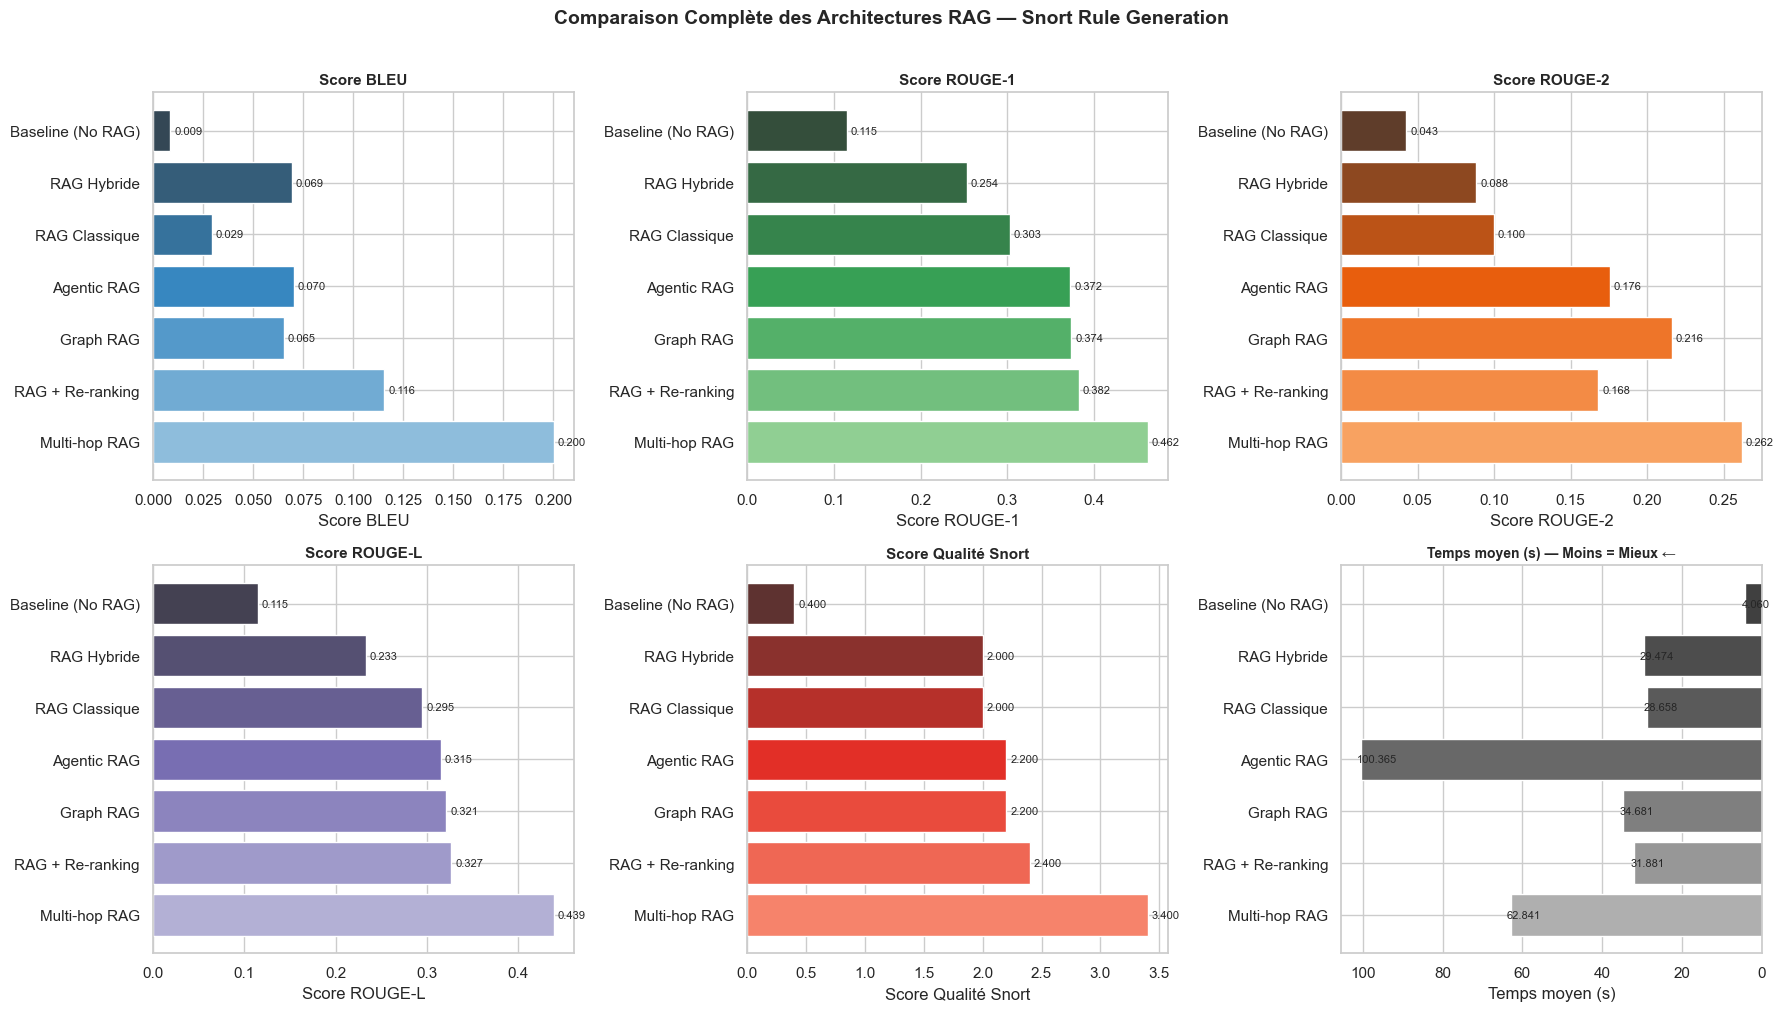

 Graphique sauvegardé dans ../Charts/10_comparison_metrics.png


In [10]:
methods      = summary.index.tolist()
palette      = sns.color_palette('tab10', len(methods))
color_dict   = dict(zip(methods, palette))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('BLEU',        'Score BLEU',         'Blues_d'),
    ('ROUGE_1',     'Score ROUGE-1',       'Greens_d'),
    ('ROUGE_2',     'Score ROUGE-2',       'Oranges_d'),
    ('ROUGE_L',     'Score ROUGE-L',       'Purples_d'),
    ('Snort_Score', 'Score Qualité Snort', 'Reds_d'),
    ('Temps_moy_s', 'Temps moyen (s)',     'Greys_d')
]

for ax, (metric, label, cmap) in zip(axes, metrics_to_plot):
    values = summary[metric].values
    colors = sns.color_palette(cmap, len(methods))
    bars   = ax.barh(methods, values, color=colors)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    if metric == 'Temps_moy_s':
        ax.invert_xaxis()  # plus c'est à gauche = plus rapide
        ax.set_title('Temps moyen (s) — Moins = Mieux ←', fontsize=10, fontweight='bold')

plt.suptitle('Comparaison Complète des Architectures RAG — Snort Rule Generation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Charts/10_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Graphique sauvegardé dans ../Charts/10_comparison_metrics.png')

## 9. Radar Chart (vue globale)

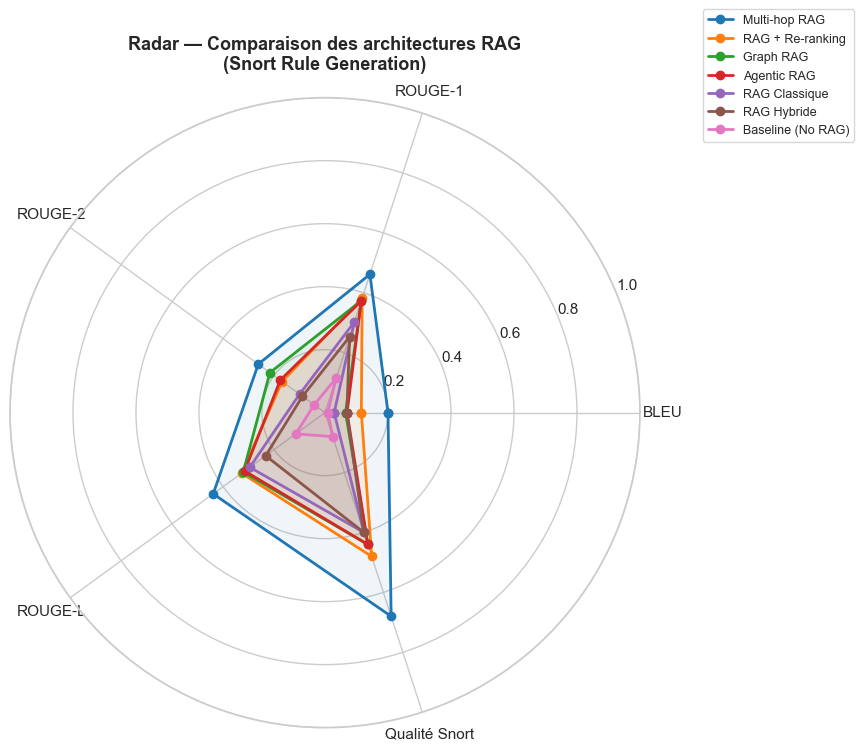

 Radar chart sauvegardé dans ../Charts/10_radar_chart.png


In [11]:
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['BLEU', 'ROUGE_1', 'ROUGE_2', 'ROUGE_L', 'Snort_Score']
# Normalisation Snort_Score sur 1
summary_norm = summary[radar_metrics].copy()
summary_norm['Snort_Score'] = summary_norm['Snort_Score'] / 5

N       = len(radar_metrics)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, (method_name, row) in enumerate(summary_norm.iterrows()):
    values_r  = row.values.tolist()
    values_r += values_r[:1]
    ax.plot(angles, values_r, 'o-', linewidth=2,
            label=method_name, color=palette[i % len(palette)])
    ax.fill(angles, values_r, alpha=0.07, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Qualité Snort'], fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Radar — Comparaison des architectures RAG\n(Snort Rule Generation)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('../Charts/10_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Radar chart sauvegardé dans ../Charts/10_radar_chart.png')

## 10. Heatmap des métriques par requête × méthode

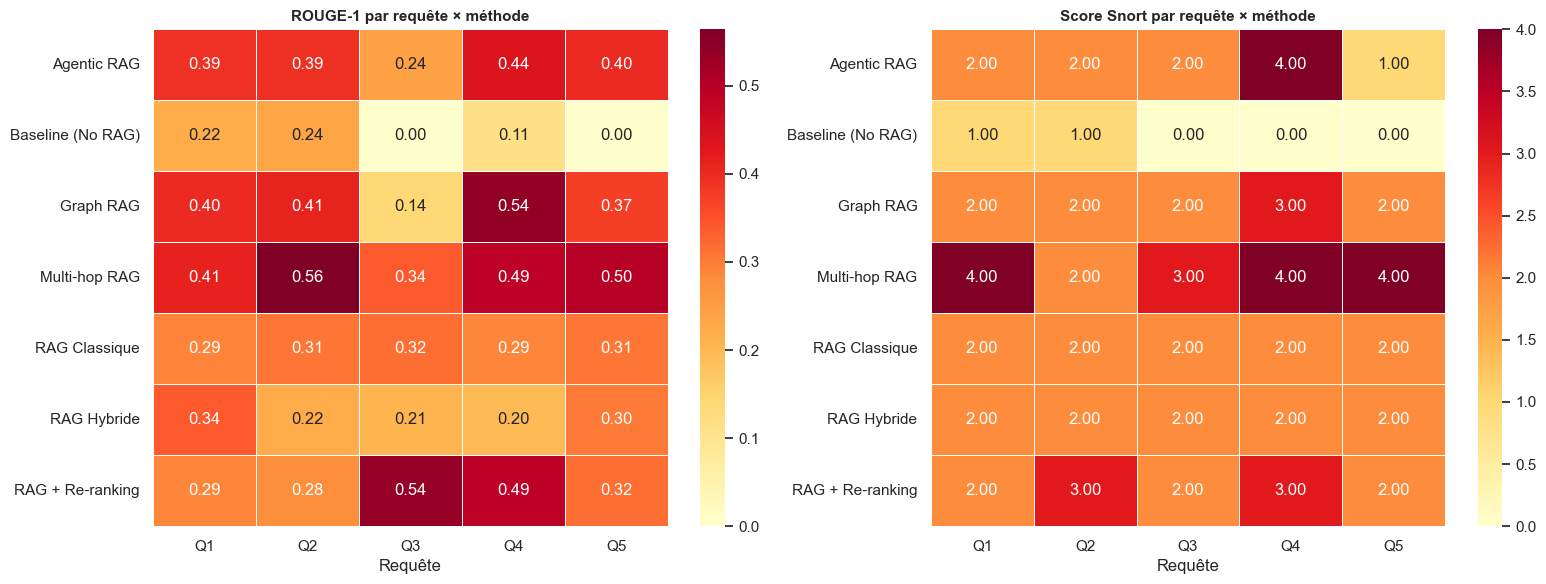

 Heatmap sauvegardée dans ../Charts/10_heatmap_queries.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in [
    (axes[0], 'rouge1',     'ROUGE-1 par requête × méthode'),
    (axes[1], 'snort_score','Score Snort par requête × méthode')
]:
    pivot = df_metrics.pivot_table(
        index='method', columns='query_id', values=metric, aggfunc='mean'
    )
    pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]
    pivot.columns = [f'Q{c}' for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, vmin=0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Requête')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../Charts/10_heatmap_queries.png', dpi=150)
plt.show()
print(' Heatmap sauvegardée dans ../Charts/10_heatmap_queries.png')

## 11. Export du tableau final en CSV

In [14]:
summary.to_csv('../Charts/10_tableau_comparatif.csv')
df_metrics.to_csv('../Charts/10_metriques_detaillees.csv', index=False)
print(' Tableaux exportés :')
print('   → ../Charts/10_tableau_comparatif.csv   (moyennes par méthode)')
print('   → ../Charts/10_metriques_detaillees.csv (toutes les métriques)')

 Tableaux exportés :
   → ../Charts/10_tableau_comparatif.csv   (moyennes par méthode)
   → ../Charts/10_metriques_detaillees.csv (toutes les métriques)


## 12. Interface Gradio
Permet de tester toutes les architectures RAG en temps réel.

In [18]:
# Chargement des ressources pour l'interface
print('Chargement des ressources pour Gradio...')
_index = faiss.read_index('../Embeddings/snort_faiss.index')
with open('../Embeddings/snort_metadata.pkl', 'rb') as f:
    _metadata = pickle.load(f)
embed_model = SentenceTransformer('all-mpnet-base-v2')
tokenizer   = AutoTokenizer.from_pretrained('Qwen/Qwen2-1.5B-Instruct')
model_llm         = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2-1.5B-Instruct', dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model_llm.eval()

def _generate(prompt):
    messages = [
        {
            "role": "system", 
            "content": "You are a Snort IDS expert. Always respond with only a valid Snort rule. Never explain, never ask questions, never apologize. Only output the raw Snort rule starting with 'alert'."
        },
        {
            "role": "user", 
            "content": prompt
        }
    ]
    
    # Appliquer le template chat de Qwen2
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model_llm.device)
    
    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=200,     
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
    # Garder seulement la ligne commençant par alert
    for line in result.split('\n'):
        if line.strip().startswith('alert'):
            return line.strip()
    
    # Si pas de alert trouvé, retourner première ligne
    return result.split('\n')[0].strip()

# BM25
_corpus = [(d['description'] + ' ' + d['attack_type'] + ' ' + d['protocol']).lower().split()
           for d in _metadata]
_bm25 = BM25Okapi(_corpus)

print(' Ressources Gradio prêtes')

Chargement des ressources pour Gradio...


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 122.30it/s]


 Ressources Gradio prêtes


In [19]:
# ─── Fonctions utilisées par l'interface ────────────────────────────────────

def _faiss_retrieve(query, k=3):
    vec = embed_model.encode([query], normalize_embeddings=True).astype('float32')
    scores, indices = _index.search(vec, k)
    return [(_metadata[int(i)].copy() | {'score': float(s)})
            for s, i in zip(scores[0], indices[0])]

def _bm25_retrieve(query, k=3):
    sc = _bm25.get_scores(query.lower().split())
    top = np.argsort(sc)[::-1][:k]
    return [(_metadata[int(i)].copy() | {'score': float(sc[i])}) for i in top]

def _format_docs(docs):
    parts = []
    for i, d in enumerate(docs, 1):
        parts.append(f"Example {i}: {d['description']}\nSnort rule: {d['snort_rule']}")
    return "\n\n".join(parts)

def run_architecture(query: str, method: str) -> str:
    """Fonction principale appelée par Gradio."""
    start = time.time()

    if method == 'Baseline (No RAG)':
        prompt   = f"Generate a valid Snort rule for: {query}\nSnort rule:"
        response = _generate(prompt)
        docs_txt = 'Aucun document récupéré'

    elif method == 'RAG Classique':
        docs     = _faiss_retrieve(query, k=3)
        ctx      = _format_docs(docs)
        prompt   = f"You are a Snort expert. Use these examples:\n{ctx}\n\nGenerate a Snort rule for: {query}\nSnort rule:"
        response = _generate(prompt)
        docs_txt = '\n'.join([f"[{d['score']:.3f}] {d['description']}" for d in docs])

    elif method == 'RAG + Re-ranking':
        from sentence_transformers import CrossEncoder
        ce   = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
        docs = _faiss_retrieve(query, k=10)
        pairs = [[query, d['description'] + ' ' + d['snort_rule']] for d in docs]
        cs   = ce.predict(pairs)
        docs = sorted(zip(docs, cs), key=lambda x: x[1], reverse=True)
        docs = [d for d, _ in docs[:3]]
        ctx  = _format_docs(docs)
        prompt   = f"You are a Snort expert. Use these re-ranked examples:\n{ctx}\n\nGenerate a Snort rule for: {query}\nSnort rule:"
        response = _generate(prompt)
        docs_txt = '\n'.join([f"{d['description']}" for d in docs])

    elif method == 'RAG Hybride':
        dense  = {int(i): float(s) for s, i in zip(
            *_index.search(embed_model.encode([query], normalize_embeddings=True).astype('float32'), 10)[::1])}
        sparse_sc = _bm25.get_scores(query.lower().split())
        sparse = {int(i): float(sparse_sc[i]) for i in np.argsort(sparse_sc)[::-1][:10]}
        rrf = {}
        for rank, idx in enumerate(sorted(dense, key=dense.get, reverse=True), 1):
            rrf[idx] = rrf.get(idx, 0) + 1/(60+rank)
        for rank, idx in enumerate(sorted(sparse, key=sparse.get, reverse=True), 1):
            rrf[idx] = rrf.get(idx, 0) + 1/(60+rank)
        top3 = sorted(rrf, key=rrf.get, reverse=True)[:3]
        docs = [_metadata[i] for i in top3]
        ctx  = _format_docs(docs)
        prompt   = f"You are a Snort expert. Use these hybrid search examples:\n{ctx}\n\nGenerate a Snort rule for: {query}\nSnort rule:"
        response = _generate(prompt)
        docs_txt = '\n'.join([f"{d['description']}" for d in docs])

    elif method == 'Multi-hop RAG':
        docs1    = _faiss_retrieve(query, k=3)
        ctx1     = '\n'.join([f"- {d['attack_type']}: {d['description']}" for d in docs1])
        ref_q    = _generate(f"Reformulate this query more specifically: {query}\nContext: {ctx1}\nRefined query:")
        docs2    = _faiss_retrieve(ref_q, k=3)
        all_docs = docs1 + docs2
        ctx      = _format_docs(all_docs)
        prompt   = f"You are a Snort expert. Use these examples from 2 retrieval hops:\n{ctx}\n\nGenerate a Snort rule for: {query}\nSnort rule:"
        response = _generate(prompt)
        docs_txt = f"Requête reformulée : {ref_q}\n" + '\n'.join([f"{d['description']}" for d in all_docs])

    elif method == 'Graph RAG':
        import networkx as nx
        G_local = nx.Graph()
        for i, doc in enumerate(_metadata):
            G_local.add_node(f'doc_{i}', **doc, doc_index=i)
        for at, grp in pd.DataFrame(_metadata).groupby('attack_type').groups.items():
            ids = list(grp)
            for a in range(len(ids)):
                for b in range(a+1, len(ids)):
                    G_local.add_edge(f'doc_{ids[a]}', f'doc_{ids[b]}')
        seeds    = _faiss_retrieve(query, k=2)
        seed_ids = [s.get('doc_index', 0) for s in seeds]
        visited  = set(f'doc_{i}' for i in seed_ids)
        for node in list(visited):
            for nbr in G_local.neighbors(node):
                visited.add(nbr)
        docs     = [G_local.nodes[n] for n in list(visited)[:5] if 'description' in G_local.nodes[n]]
        ctx      = _format_docs(docs)
        prompt   = f"You are a Snort expert. Use these graph-retrieved examples:\n{ctx}\n\nGenerate a Snort rule for: {query}\nSnort rule:"
        response = _generate(prompt)
        docs_txt = '\n'.join([d.get('description','') for d in docs])

    elif method == 'Agentic RAG':
        response = ''
        docs_txt = ''
        for iteration in range(1, 4):
            docs     = _faiss_retrieve(query, k=2+iteration)
            ctx      = _format_docs(docs)
            prompt   = f"You are a Snort expert (attempt {iteration}). Generate a COMPLETE Snort rule with alert, msg, sid, content.\n{ctx}\n\nSnort rule for: {query}\nSnort rule:"
            response = _generate(prompt)
            score    = sum([response.startswith('alert'), 'msg:' in response,
                            'sid:' in response, any(p in response for p in ['tcp','udp','icmp'])])
            docs_txt = f'Itération {iteration} — Score {score}/4\n' + '\n'.join([d['description'] for d in docs])
            if score >= 3:
                break
    else:
        response = 'Méthode inconnue'
        docs_txt = ''

    elapsed = round(time.time() - start, 3)
    quality = compute_snort_quality(response)

    output = f"""{'='*60}
  Requête     : {query}
  Méthode     : {method}
  Temps       : {elapsed}s
{'='*60}

 Documents récupérés :
{docs_txt}

{'='*60}
 Règle Snort générée :
{response}

{'='*60}
 Qualité Snort : {quality['score']}/5
   alert={quality['alert']} | msg={quality['msg']} | sid={quality['sid']} | protocol={quality['protocol']} | content={quality['content']}
"""
    return output


print(' Fonctions Gradio définies')

 Fonctions Gradio définies


In [23]:
# ─── Interface Gradio ────────────────────────────────────────────────────────

METHODS = [
    'Baseline (No RAG)',
    'RAG Classique',
    'RAG + Re-ranking',
    'RAG Hybride',
    'Multi-hop RAG',
    'Graph RAG',
    'Agentic RAG'
]

EXAMPLE_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware chiffrant des fichiers via SMB",
    "Repérer une exfiltration de données DNS",
    "Détecter une exploitation de Log4Shell",
    "Bloquer un trafic de minage de cryptomonnaie"
]

with gr.Blocks(title='RAG Snort Rule Generator', theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    #  Générateur de Règles Snort — Comparaison RAG
    **Devoir 3 NLP 2026 — Sujet 2 : Génération de règles SNORT**
    Testez et comparez 7 architectures RAG pour la génération automatique de règles Snort.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            query_input = gr.Textbox(
                label=' Description de l\'attaque réseau',
                placeholder='Ex: Détecter un scan de ports SYN sur un serveur web...',
                lines=3
            )
            method_radio = gr.Radio(
                choices=METHODS,
                value='RAG Classique',
                label='⚙ Architecture RAG'
            )
            run_btn = gr.Button(' Générer la règle Snort', variant='primary')

        with gr.Column(scale=3):
            output_box = gr.Textbox(
                label=' Résultat',
                lines=22,
                interactive=False
            )

    gr.Markdown('###  Requêtes exemples')
    with gr.Row():
        for ex in EXAMPLE_QUERIES[:4]:
            gr.Button(ex[:45] + '...', size='sm').click(
                fn=lambda q=ex: q,
                outputs=query_input
            )

    with gr.Row():
        for ex in EXAMPLE_QUERIES[4:]:
            gr.Button(ex[:45] + '...', size='sm').click(
                fn=lambda q=ex: q,
                outputs=query_input
            )

    with gr.Accordion(' Tableau comparatif (résultats pré-calculés)', open=False):
        table_status = gr.Markdown('*Vérification des modèles chargés...*')
        table_df = gr.Dataframe(label='Métriques moyennes par architecture', visible=False)
        gen_btn = gr.Button(' Générer / Mettre à jour le tableau', variant='secondary', visible=False)
        save_msg = gr.Markdown('', visible=False)

    def update_table_visibility():
        n_models = len([m for m in all_results if len(all_results[m]) > 0])
        if n_models >= 2:
            try:
                df_display = pd.read_csv('../Charts/10_tableau_comparatif.csv', index_col=0)
                return (
                    gr.Markdown(visible=False),
                    gr.Dataframe(value=df_display.reset_index(), visible=True),
                    gr.Button(visible=True, variant='primary'),
                    gr.Markdown(visible=False)
                )
            except FileNotFoundError:
                return (
                    gr.Markdown(f'*{n_models} modèles chargés. Cliquez sur le bouton pour générer le tableau.*', visible=True),
                    gr.Dataframe(visible=False),
                    gr.Button(visible=True),
                    gr.Markdown(visible=False)
                )
        else:
            return (
                gr.Markdown(f'*⚠ {n_models}/7 modèles chargés. Exécutez au moins 2 notebooks de génération de règles (03-09) pour voir le tableau.*', visible=True),
                gr.Dataframe(visible=False),
                gr.Button(visible=False),
                gr.Markdown(visible=False)
            )

    def generate_and_save_table():
        """Recalcule les métriques à partir de all_results actuels et sauvegarde."""
        rows = []
        for method, results in all_results.items():
            for i, (result, reference) in enumerate(zip(results, GROUND_TRUTH)):
                response  = extract_response(result)
                bleu      = compute_bleu(response, reference)
                rouge_s   = compute_rouge(response, reference)
                snort_q   = compute_snort_quality(response)
                total_t   = extract_time(result)
                rows.append({
                    'method': method, 'query_id': i + 1,
                    'bleu': bleu, 'rouge1': rouge_s['rouge1'],
                    'rouge2': rouge_s['rouge2'], 'rougeL': rouge_s['rougeL'],
                    'snort_score': snort_q['score'], 'total_time': total_t
                })
        df = pd.DataFrame(rows)
        summary = df.groupby('method').agg(
            BLEU=('bleu', 'mean'), ROUGE_1=('rouge1', 'mean'),
            ROUGE_2=('rouge2', 'mean'), ROUGE_L=('rougeL', 'mean'),
            Snort_Score=('snort_score', 'mean'), Temps_moy_s=('total_time', 'mean')
        ).round(4)
        summary.index = [METHOD_LABELS.get(m, m) for m in summary.index]
        summary = summary.sort_values('ROUGE_L', ascending=False)
        summary.to_csv('../Charts/10_tableau_comparatif.csv')
        df.to_csv('../Charts/10_metriques_detaillees.csv', index=False)
        return (
            gr.Markdown(visible=False),
            gr.Dataframe(value=summary.reset_index(), visible=True),
            gr.Button(visible=True, variant='primary'),
            gr.Markdown(f'*✔ Tableau sauvegardé : ../Charts/10_tableau_comparatif.csv*', visible=True)
        )

    demo.load(update_table_visibility, outputs=[table_status, table_df, gen_btn, save_msg])
    gen_btn.click(fn=generate_and_save_table, outputs=[table_status, table_df, gen_btn, save_msg])

    run_btn.click(
        fn=run_architecture,
        inputs=[query_input, method_radio],
        outputs=output_box
    )

demo.launch(share=False, server_port=7862)
print(' Interface Gradio lancée sur http://localhost:7862')

C:\Users\takie\AppData\Local\Temp\ipykernel_15388\4200902947.py:23: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title='RAG Snort Rule Generator', theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


 Interface Gradio lancée sur http://localhost:7862


---
## ✅ Résumé

| Étape | Détail |
|---|---|
| Métriques textuelles | BLEU, ROUGE-1, ROUGE-2, ROUGE-L |
| Métrique domaine | Score Snort (5 critères) |
| Architectures évaluées | 7 (Baseline → Agentic) |
| Requêtes testées | 5 × 7 = 35 évaluations |
| Interface | Gradio `http://localhost:7862` |
| Fichiers de sortie | `10_tableau_comparatif.csv`, `10_metriques_detaillees.csv` |

### Tableau comparatif final

| Architecture | BLEU | ROUGE-1 | ROUGE-2 | ROUGE-L | Snort Score | Temps moy. |
|---|---|---|---|---|---|---|
| **Multi-hop RAG** | **0.2001** | **0.4618** | **0.2618** | **0.4387** | **3.4 / 5** | 62.8s |
| RAG + Re-ranking | 0.1155 | 0.3822 | 0.1682 | 0.3268 | 2.4 / 5 | 31.9s |
| Graph RAG | 0.0653 | 0.3737 | 0.2161 | 0.3209 | 2.2 / 5 | 34.7s |
| Agentic RAG | 0.0702 | 0.3724 | 0.1756 | 0.3152 | 2.2 / 5 | 100.4s |
| RAG Classique | 0.0292 | 0.3028 | 0.0998 | 0.2951 | 2.0 / 5 | 28.7s |
| RAG Hybride | 0.0693 | 0.2535 | 0.0883 | 0.2328 | 2.0 / 5 | 29.5s |
| Baseline (No RAG) | 0.0086 | 0.1148 | 0.0425 | 0.1148 | 0.4 / 5 | 4.1s |

### Observations clés
- 🥇 **Multi-hop RAG** remporte toutes les métriques : BLEU, ROUGE-L et Snort Score — le double retrieval avec reformulation est l'approche la plus efficace
- 🥈 **RAG + Re-ranking** offre le meilleur rapport qualité/temps (~31.9s, ROUGE-L=0.33)
- ⚠️ **Agentic RAG** est le plus lent (~100.4s) pour un Snort Score identique au Graph RAG (2.2/5) — coût non justifié
- ⚠️ **RAG Hybride** déçoit malgré la fusion Dense+BM25 — pire ROUGE-1 et Snort Score ex-æquo avec le RAG Classique
- ✅ Toute architecture RAG surpasse largement la Baseline (ROUGE-L : 0.11 → 0.44 au maximum)

### Limites de l'évaluation
- ❌ `content` quasi absent dans toutes les règles — les métriques ROUGE récompensent la forme, pas la validité Snort
- ❌ BLEU reste faible même pour le meilleur modèle (0.20) — génération peu précise au niveau token
- ⚠️ Ground truth manuelle pour 5 requêtes seulement — dataset d'évaluation trop petit pour être conclusif

### Conclusion générale
Le **Multi-hop RAG** est l'architecture gagnante sur ce benchmark.
Le retrieval en deux passes avec reformulation compense mieux les limites du LLM que la complexité structurelle (Graph) ou la boucle itérative (Agentic).
L'interface Gradio permet de tester toutes les architectures en temps réel et constitue un bon point de départ pour des expérimentations futures avec un LLM plus puissant.